# Two Parks, Two Vacant Lots, and 1,254 Votes

In [1]:
import json, re
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import re

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu, spearmanr

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#a5a49e"
pd.set_option("display.max_colwidth", 200)
con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers", "incidents", "cannabis"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

# full-text index: meeting_id -> complete minutes text (text layer + vision OCR)
_meet = json.loads(Path("../data/meetings.json").read_text())["meetings"]
_sha2mid = {f["sha256"]: mid for mid, m in _meet.items() for f in m["files"]}
_texts = {}
for _tf in Path("../data/interim/text").glob("*.json"):
    _mid = _sha2mid.get(_tf.stem)
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + " ".join(json.loads(_tf.read_text()))
for _of in Path("../data/interim/ocr").glob("*.txt"):
    _mid = _sha2mid.get(_of.name[:64])
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + _of.read_text()
_lower = {m: t.lower() for m, t in _texts.items()}
_dates = {m: v["date"] for m, v in _meet.items()}
lower = _lower
dates = _dates
def mentions(term):
    """Meetings where `term` appears, with counts. Case-insensitive."""
    term = term.lower()
    return pd.DataFrame(
        [(m, _dates[m], _lower[m].count(term)) for m in _lower if term in _lower[m]],
        columns=["meeting_id", "date", "n"],
    ).sort_values("date").reset_index(drop=True)

def context(term, meeting_id, width=200, k=5):
    """Verbatim passages around each occurrence of `term` in one meeting."""
    out = []
    for m in re.finditer(re.escape(term.lower()), _lower[meeting_id]):
        s = max(0, m.start() - width)
        out.append(" ".join(_texts[meeting_id][s : m.end() + width].split()))
        if len(out) >= k:
            break
    return out

print(f"{len(_texts)} meetings indexed, {sum(len(t) for t in _texts.values())/1e6:.0f}M chars")
wf = pd.DataFrame(
    [(m, _meet[m]["date"], _lower[m].count("waterfront")) for m in _lower],
    columns=["meeting_id", "date", "wf_mentions"],
)
wf["date"] = pd.to_datetime(wf.date)
wf_meetings = wf[wf.wf_mentions > 0].sort_values("date").reset_index(drop=True)


110 meetings indexed, 31M chars


![Bushwick Inlet Park from the community center's green roof, April 2026: the soccer field in use on the left - and one of the two vacant lots on the right. Photo: author](images/bip_and_lots.jpg)


::: {.tldr}
**TLDR:** There are vacant waterfront lots in north Williamsburg that are both high value and underutilized. This area was rezoned to be a public park in 2005. I conducted a data study to learn how the community has shown up to voice frustration over this delay.
In 10 years of Community Board 1 meeting notes, the local advisory board for North Brooklyn, community turnout never clearly and directly impacted a single land use vote. Community outreach correlates with binding conditions attached to approvals.
:::



## The Backstory

There's a long backstory to the North Brooklyn waterfront. Over the last 20+ years this neighborhood has changed a lot. Williamsburg used to be home to local industry, for example my apartment building used to be a zipper factory. Currently Williamsburg is dominated by luxury condos and retail. The waterfront was owned by a combination of the city, state, and private owners, then in 2005 then-Mayor Bloomberg made a deal to rezone the north Brooklyn waterfront. The plan allowed the building of luxury high rise residential towers, increasing land value for private owners, and promised a waterfront park for the growing community. Since then, the waterfront luxury high rises have been built and continue to go up. Yet - we still only have a portion of the promised 28 acre park in Bushwick Inlet Park.

It's been two decades, where's our park?

![Navy airplanes over Greenpoint, May 1930. The piers, rail yards, and tank farms below are the land in focus for this article. Photo: [U.S. National Archives](https://commons.wikimedia.org/wiki/File:New_York_-_Brooklyn_-_NARA_-_68145045.jpg), public domain](images/aerial_1930_web.jpg)

I was curious how the community can show up and make change happen. There are several community organizations focused on advocacy for different parts of the waterfront: Friends of Bushwick Inlet Park, North Brooklyn Neighbors, North Brooklyn Parks Alliance, Brooklyn Greenway Initiative, Newtown Creek Alliance, Friends of WNYC Transmitter Park. I wanted to get a sense of how these organizations play a role in pressuring government to develop this park. This land is governed by Brooklyn Community Board 1 (CB1), the local advisory board for Williamsburg and Greenpoint. Every land use application has to come through it for a public hearing and a recommendation before the city decides.

## Scraping the minutes

CB1 posts its [meeting minutes online](https://www.nyc.gov/site/brooklyncb1/meetings/minutes.page). I created an automated script (code linked below) to scrape the pdfs and build a dataset of the key datapoints for these meetings.

The dataset covers all of CB1's 110 meetings, 1,254 votes, and 1,369 speakers. The analysis will focus on the 97 meetings where the term 'waterfront' appears.

Each record is categorized by subject - land use, liquor, parks, environment, transportation, budget. These buckets loosely mirror the board's own committee structure. Because each vote is not explicitly categorized in the notes, I labeled each motion via LLM.

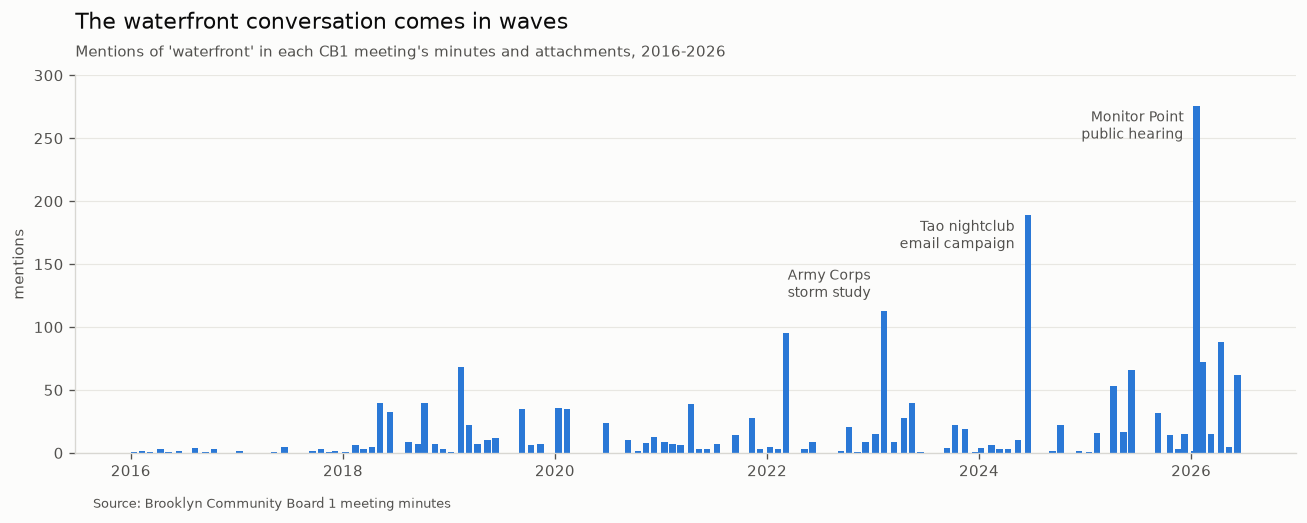

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.2), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.bar(wf_meetings.date, wf_meetings.wf_mentions, width=22, color=BLUE)
for d, v, label in [("2026-01-20", 276, "Monitor Point\npublic hearing"),
                    ("2024-06-18", 189, "Tao nightclub\nemail campaign"),
                    ("2023-02-07", 113, "Army Corps\nstorm study")]:
    ax.annotate(label, (pd.Timestamp(d), v),
                xytext=(-8, 26 if "Army" in label else -2),
                textcoords="offset points", ha="right", va="top",
                fontsize=8.5, color=INK2)
ax.set_ylim(0, 300)
ax.set_ylabel("mentions", fontsize=9, color=INK2)
ax.tick_params(colors=INK2, labelsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#d8d7d2"); ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="y", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)
ax.set_title("The waterfront conversation comes in waves",
             fontsize=13, color=INK, loc="left", pad=28)
ax.text(0, 1.05, "Mentions of 'waterfront' in each CB1 meeting's minutes and attachments, 2016-2026",
        transform=ax.transAxes, fontsize=9, color=INK2)
fig.text(0.075, -0.02, "Source: Brooklyn Community Board 1 meeting minutes",
         fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

You can see that the term waterfront shows up frequently, with a few spikes in activity. A few highlights with details of what was discussed:

January 20, 2026 — 276 mentions. This is a public hearing focused exclusively on Monitor Point. The notes are mostly written testimony from individuals and community groups including Veronica Zapasnik, a Polish immigrant who's been in the neighborhood since 1990, and NYSAFAH (the New York State Association for Affordable Housing). The opposition testimony repeats one claim: the rezoning of this land into a set of residential towers breaks a two-decade-old promise to make this land into a waterfront park for all.

June 18, 2024 — 189 mentions. There is a swarm of emails to the board about the proposal to open a Tao nightclub next to Bushwick Inlet Park, including one template that was re-sent over 100 times. The letter focuses on the habitat restoration at the Inlet and the noise pollution a club would bring.

## What does the board actually fight about?

First question: does the board ever actually disagree? Do votes get contested - and over what? If we're looking for the impact of a community organization, unaminous yes votes and no votes are likely useless. I wanted to find cases where the community shows up and is able to flip some votes to 'no.'

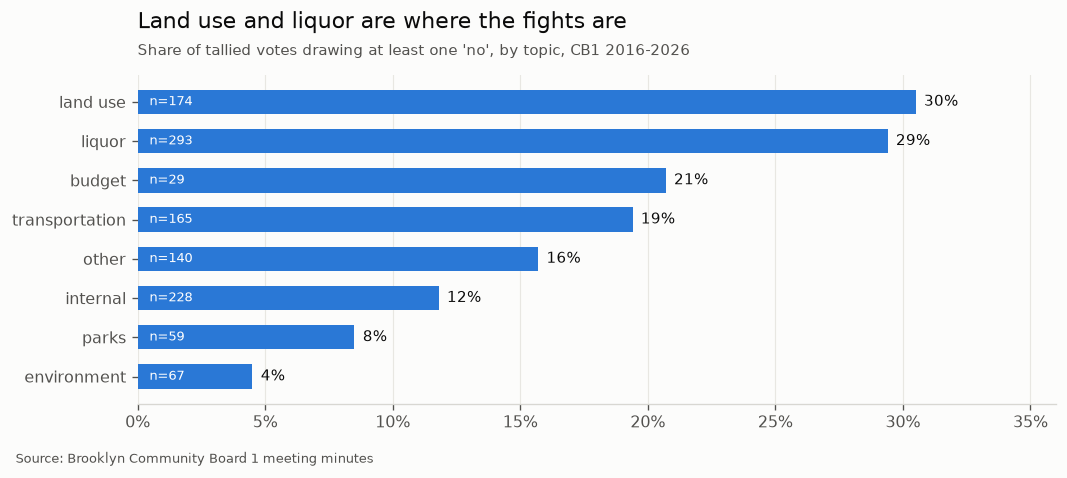

In [3]:
rates = q("""
    SELECT topic_category, count(*) AS n,
           round(avg(CASE WHEN no > 0 THEN 1 ELSE 0 END), 3) AS contested_rate,
           round(stddev_samp(CASE WHEN no > 0 THEN 1 ELSE 0 END), 3) AS std_dev
    FROM votes WHERE yes + no > 0
    GROUP BY 1 ORDER BY contested_rate DESC
""")
NAMES = {"land_use": "land use"}
r = rates.assign(topic=rates.topic_category.map(lambda t: NAMES.get(t, t))).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 3.8), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.barh(r.topic, r.contested_rate, height=0.62, color=BLUE)
for y, (rate, n) in enumerate(zip(r.contested_rate, r.n)):
    ax.annotate(f"{rate:.0%}", (rate, y), xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK)
    ax.annotate(f"n={n}", (0.002, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=7.5, color="#ffffff")
ax.set_xlim(0, 0.36)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.tick_params(colors=INK2, labelsize=9.5)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="x", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)
ax.set_title("Land use and liquor are where the fights are",
             fontsize=13, color=INK, loc="left", pad=28)
ax.text(0, 1.06, "Share of tallied votes drawing at least one 'no', by topic, CB1 2016-2026",
        transform=ax.transAxes, fontsize=9, color=INK2)
fig.text(0.02, -0.03, "Source: Brooklyn Community Board 1 meeting minutes",
         fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

The above graphic plots the share of votes in each topic drawing at least one 'no'. This is a simple way to measure how often the board splits on a motion. Looking at the park and environment votes - we see that these votes are rarely contested at 8% and 4% respectively. It turns out that most of the debate around the park development actually happens in 'land use' votes and we see those votes are heavily contested. 30% of votes on land use draw at least one 'no' vote.

So land use votes draw debate, but can we find out why? What data points would help us predict a contested vote?

I ran a regression to find out the relationship between the number of public speakers and the likelihood of a contested vote. Across all 1,150 tallied votes, controlling for topic, attendance, and year, with errors clustered by meeting, the strongest predictor of a contested vote was the topic of the vote. The number of public speakers at a meeting has no significant relationship with whether a vote that night draws a 'no', even when counting only speakers who took a side. A contested vote is just as likely at a quiet meeting as at a packed one.


turnout (log speakers): OR 1.227, p=0.105 (n=1150)
land use only: p=0.976 (n=172)


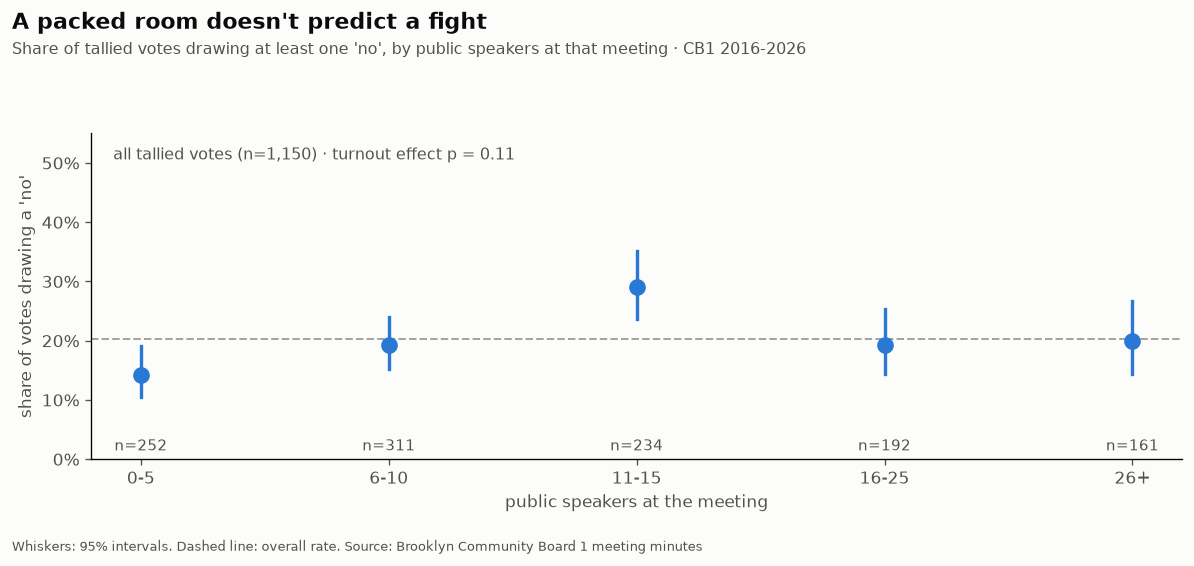

In [4]:
# Does turnout predict a contested vote? Logistic regression over all tallied
# votes (errors clustered by meeting). The figure: contested share by
# how many people spoke at that meeting.
from statsmodels.stats.proportion import proportion_confint

reg = q("""
    SELECT v.meeting_id, v.topic_category, v.no,
           m.attendance_count, year(m.date) AS yr,
           (SELECT count(*) FROM speakers s WHERE s.meeting_id = v.meeting_id) AS n_speakers,
           (SELECT count(*) FROM speakers s WHERE s.meeting_id = v.meeting_id
              AND s.position IN ('for','against')) AS n_pos_speakers
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.yes + v.no > 0
""").dropna(subset=["attendance_count"])
reg["contested"] = (reg.no > 0).astype(int)

fit = smf.logit(
    "contested ~ np.log1p(n_speakers) + C(topic_category, Treatment('liquor'))"
    " + attendance_count + I(yr-2016)",
    data=reg,
).fit(disp=0, cov_type="cluster", cov_kwds={"groups": reg.meeting_id})
p_turnout = fit.pvalues["np.log1p(n_speakers)"]
print(f"turnout (log speakers): OR {np.exp(fit.params['np.log1p(n_speakers)']):.3f}, "
      f"p={p_turnout:.3f} (n={len(reg)})")

lu = reg[reg.topic_category == "land_use"]
f_lu = smf.logit("contested ~ np.log1p(n_speakers) + attendance_count + I(yr-2016)",
                 data=lu).fit(disp=0, cov_type="cluster", cov_kwds={"groups": lu.meeting_id})
p_lu = f_lu.pvalues["np.log1p(n_speakers)"]
print(f"land use only: p={p_lu:.3f} (n={len(lu)})")

def buckets(d, edges, labels):
    out = []
    grp = pd.cut(d.n_speakers, edges, labels=labels)
    for lab, g in d.groupby(grp, observed=True):
        k, n = g.contested.sum(), len(g)
        lo, hi = proportion_confint(k, n, method="wilson")
        out.append((lab, n, k / n, lo, hi))
    return out

def bucket_axis(ax, bk, base, note):
    ax.set_facecolor(SURFACE)
    xs = range(len(bk))
    ax.axhline(base, color=GRAY, lw=1.2, ls="--", zorder=1)
    for x, (lab, n, p, lo, hi) in zip(xs, bk):
        ax.plot([x, x], [lo, hi], color=BLUE, lw=2, zorder=2)
        ax.plot(x, p, "o", color=BLUE, ms=9, zorder=3)
        ax.annotate(f"n={n}", (x, 0.015), ha="center", fontsize=9, color=INK2)
    ax.set_xticks(list(xs), [b[0] for b in bk], fontsize=10)
    ax.annotate(note, (0.02, 0.92), xycoords="axes fraction", fontsize=9.5, color=INK2)
    ax.annotate(f"overall rate {base:.0%}", (len(bk) - 0.55, base + 0.02),
                ha="right", fontsize=9, color=INK2)
    ax.set_ylim(0, 0.55)
    ax.set_ylabel("share of votes drawing a 'no'", fontsize=10, color=INK2)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.set_xlabel("public speakers at the meeting", fontsize=10, color=INK2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=INK2)

SRC = "Source: Brooklyn Community Board 1 meeting minutes"

# --- figure 1: all tallied votes ---
fig, ax = plt.subplots(figsize=(10, 4.4), dpi=120)
fig.patch.set_facecolor(SURFACE)
bucket_axis(ax, buckets(reg, [-1, 5, 10, 15, 25, 999],
                        ["0-5", "6-10", "11-15", "16-25", "26+"]),
            reg.contested.mean(), f"all tallied votes (n={len(reg):,}) · turnout effect p = {p_turnout:.2f}")
fig.suptitle("A packed room doesn't predict a fight", fontsize=13, color=INK,
             x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.9, "Share of tallied votes drawing at least one 'no', by public speakers "
         "at that meeting · CB1 2016-2026", fontsize=9.5, color=INK2)
fig.text(0.01, -0.02, "Whiskers: 95% intervals. Dashed line: overall rate. " + SRC,
         fontsize=8, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()

The chart above shows the model output: the share of contested votes at meetings with increasing amounts of public speakers. The buckets hug the average and the intervals overlap, showing no clear effect of more public speakers on CB1 discord. Even restricting to just land use votes - the votes that decide what gets built - we get the same result (p = 0.98).

This analysis was done using a logistic regression that predicts whether a vote draws at least one 'no'. The inputs are the vote's topic, the number of public speakers at that meeting, the board's attendance, and the year. I clustered votes by meeting as a way to control for one meeting having more divisive votes than another meeting. Board division is the dependent variable here because it's the clearest signal in the record: a 'no' means somebody on the board pushed back. The ideal alternative - checking whether the board voted the way the community asked - can't be done at scale with this dataset, because of issues with this dataset. First - there are not enough votes with public turnour to draw a conclusion. Second, many motions only exist because the community asked for them.

So turnout doesn't correlate with division the way the board votes. What impact does the community have then?

## Showing up - at the mic and in writing

Our dataset of CB1 meetings contain datapoints on two main ways the community can show up: public speakers and written testimony. 


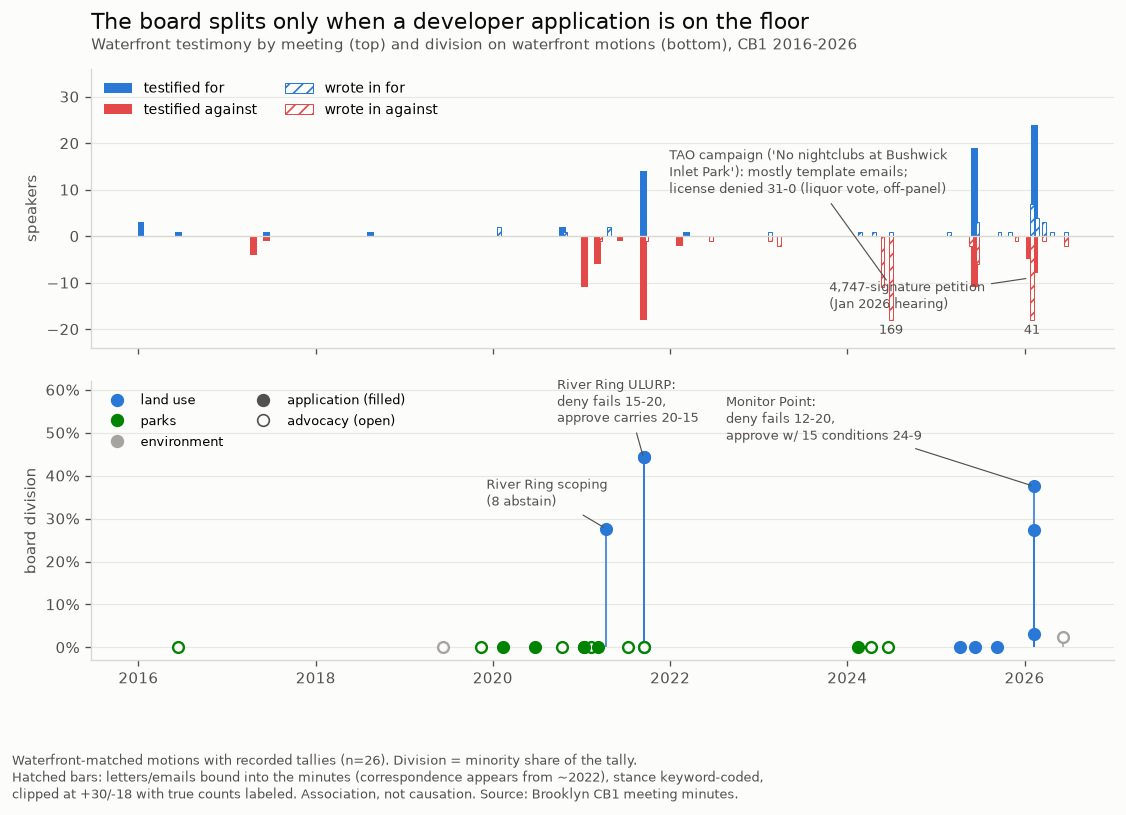

In [5]:
# waterfront votes: matcher + features (also used by the votes table below)
WF = ("(bushwick inlet|monitor point|river ring|quay|65 commercial|56 quay|"
      "40 quay|waterfront|esplanade|demapp|marsha p|inlet park|fbip|open space)")

wfv = q(f"""
    SELECT v.meeting_id, m.date, v.motion_text, v.topic_category,
           v.yes, v.no, v.abstain, v.outcome, len(v.conditions) AS num_conditions_attached
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.topic_category IN ('land_use','parks','environment')
      AND regexp_matches(lower(v.motion_text), '{WF}')
      AND NOT regexp_matches(lower(v.motion_text), 'link5g')
      AND v.yes + v.no > 0
    ORDER BY date
""")
tot = wfv.yes + wfv.no + wfv.abstain
wfv["division"] = (tot - wfv[["yes", "no"]].max(axis=1)) / tot
APP = re.compile(r"application|ulurp|ceqr|proposal|scoping|design|demapp", re.I)
wfv["kind"] = wfv.motion_text.map(
    lambda t: "application" if APP.search(t) else "advocacy")
wfv["date"] = pd.to_datetime(wfv.date)

per_meet = q(f"""
    SELECT m.date,
           count(*) FILTER (s.position = 'for') AS n_for,
           count(*) FILTER (s.position = 'against') AS n_against
    FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE regexp_matches(lower(s.topic), '{WF}')
    GROUP BY 1 ORDER BY 1
""")
per_meet["date"] = pd.to_datetime(per_meet.date)


# mail, with direction (parser shared with the letters section below): split
# each meeting's attachment pages into individual letters/emails, keep the
# waterfront ones, keyword-code each item's stance (see methodology).
MAIL_BOUND = re.compile(
    r"From: [A-Z][A-Za-z .’'-]{3,40}? Sent: |"
    r"Dear (?:Chair|Chairperson|Community Board|CB ?1|Members|Board|Mr\.|Ms\.|"
    r"Sir|Madam|District Manager)|To Whom It May Concern", re.I)
MAIL_AGAINST = re.compile(
    r"oppos|against|deny|denial|reject|do not approve|vote no|say no|no to |"
    r"stop (?:the|this)|not support|withdraw|concern|urge.{0,30}(?:deny|no\b)", re.I)
MAIL_FOR = re.compile(
    r"\bsupport|in favor|approve|endorse|urge.{0,30}(?:approve|yes\b)|"
    r"vote yes|stand with", re.I)

_mail_ocr = {}
for _of in Path("../data/interim/ocr").glob("*.txt"):
    _sha, _p = _of.stem.rsplit("-p", 1)
    _mail_ocr.setdefault(_sha, []).append((int(_p), _of))

def _mail_items(mid):
    att = ""
    for f in _meet[mid]["files"]:
        sha = f["sha256"]
        sf = Path(f"../data/interim/segments/{sha}.json")
        if not sf.exists():
            continue
        body = set(json.loads(sf.read_text())["body_pages"])
        tp = Path(f"../data/interim/text/{sha}.json")
        pages = json.loads(tp.read_text()) if tp.exists() else []
        att += " ".join(p for i, p in enumerate(pages) if i not in body)
        for pno, of in _mail_ocr.get(sha, []):
            if pno not in body:
                att += " " + of.read_text()
    t = " ".join(att.split())
    idxs = [b.start() for b in MAIL_BOUND.finditer(t)]
    return [t[st:min((idxs[j + 1] if j + 1 < len(idxs) else st + 1500), st + 2500)]
            for j, st in enumerate(idxs)]

def _mail_stance(txt):
    t = re.sub(r"[‘’“”\"']", "", txt)
    a, f = len(MAIL_AGAINST.findall(t)), len(MAIL_FOR.findall(t))
    return "against" if a > f else "for" if f > a else "unclear"

_mid_by_date = {v: k for k, v in _dates.items()}
_WF_RE = re.compile(WF, re.I)
_mrows = []
for _mid in _meet:
    _its = [it for it in _mail_items(_mid) if _WF_RE.search(it)]
    if not _its:
        continue
    _s = pd.Series([_mail_stance(it) for it in _its]).value_counts()
    _mrows.append({"date": pd.Timestamp(_meet[_mid]["date"]),
                   "m_for": int(_s.get("for", 0)),
                   "m_against": int(_s.get("against", 0))})
mail_pm = pd.DataFrame(_mrows).sort_values("date")
mail_pm = mail_pm[(mail_pm.m_for > 0) | (mail_pm.m_against > 0)]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 6.4), dpi=120, sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})
fig.patch.set_facecolor(SURFACE)
W = 28  # bar width, days
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color("#d8d7d2")
    ax.spines["bottom"].set_color("#d8d7d2")
    ax.tick_params(colors=INK2, labelsize=9)

ax1.bar(per_meet.date, per_meet.n_for, width=W, color=BLUE, label="testified for")
ax1.bar(per_meet.date, -per_meet.n_against, width=W, color=RED,
        label="testified against")
CLIP_UP, CLIP_DN = 30, 18
_off = pd.Timedelta(days=11)
ax1.bar(mail_pm.date + _off, mail_pm.m_for.clip(upper=CLIP_UP), width=W * 0.55,
        facecolor=SURFACE, edgecolor=BLUE, hatch="///", lw=0.6,
        label="wrote in for")
ax1.bar(mail_pm.date + _off, -mail_pm.m_against.clip(upper=CLIP_DN), width=W * 0.55,
        facecolor=SURFACE, edgecolor=RED, hatch="///", lw=0.6,
        label="wrote in against")
for _d, _v in mail_pm[mail_pm.m_for > CLIP_UP].set_index("date").m_for.items():
    ax1.annotate(f"{_v}", (_d + _off, CLIP_UP + 0.8), ha="center", va="bottom",
                 fontsize=8, color=INK2)
for _d, _v in mail_pm[mail_pm.m_against > CLIP_DN].set_index("date").m_against.items():
    ax1.annotate(f"{_v}", (_d + _off, -CLIP_DN - 0.8), ha="center", va="top",
                 fontsize=8, color=INK2)
ax1.set_ylim(-24, 36)
ax1.axhline(0, color="#d8d7d2", lw=0.8)
ax1.set_ylabel("speakers", fontsize=9, color=INK2)
ax1.legend(loc="upper left", frameon=False, fontsize=8.5, ncol=2)
ax1.grid(axis="y", color="#e8e7e2", lw=0.7)
ax1.set_axisbelow(True)
ax1.annotate("4,747-signature petition\n(Jan 2026 hearing)",
             (pd.Timestamp("2026-01-20"), -9), xytext=(-120, -18),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax1.annotate("TAO campaign ('No nightclubs at Bushwick\nInlet Park'): mostly template emails;\nlicense denied 31-0 (liquor vote, off-panel)",
             (pd.Timestamp("2024-06-18"), -10), xytext=(0.565, 0.72),
             textcoords="axes fraction", fontsize=8, color=INK2, va="top",
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax1.set_title("The board splits only when a developer application is on the floor",
              fontsize=13, color=INK, loc="left", pad=24)
ax1.text(0, 1.07, "Waterfront testimony by meeting (top) and division on waterfront motions (bottom), CB1 2016-2026",
         transform=ax1.transAxes, fontsize=9, color=INK2)

GREEN = "#008300"
TOPIC_COLOR = {"land_use": BLUE, "parks": GREEN, "environment": GRAY}
for (topic, kind), g in wfv.groupby(["topic_category", "kind"]):
    color = TOPIC_COLOR[topic]
    face = color if kind == "application" else SURFACE
    ax2.vlines(g.date, 0, g.division, color=color, lw=1.2, alpha=0.8)
    ax2.scatter(g.date, g.division, s=42, facecolor=face, edgecolor=color,
                lw=1.4, zorder=3)
ax2.set_ylabel("board division", fontsize=9, color=INK2)
ax2.set_ylim(-0.03, 0.62)
ax2.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
from matplotlib.lines import Line2D
handles = [
    Line2D([], [], marker="o", ls="", mfc=BLUE, mec=BLUE, ms=7, label="land use"),
    Line2D([], [], marker="o", ls="", mfc=GREEN, mec=GREEN, ms=7, label="parks"),
    Line2D([], [], marker="o", ls="", mfc=GRAY, mec=GRAY, ms=7, label="environment"),
    Line2D([], [], marker="o", ls="", mfc=INK2, mec=INK2, ms=7, label="application (filled)"),
    Line2D([], [], marker="o", ls="", mfc=SURFACE, mec=INK2, ms=7, label="advocacy (open)"),
]
ax2.legend(handles=handles, loc="upper left", frameon=False, fontsize=8, ncol=2)
ax2.grid(axis="y", color="#e8e7e2", lw=0.7)
ax2.set_axisbelow(True)
ax2.annotate("River Ring scoping\n(8 abstain)", (pd.Timestamp("2021-04-13"), 0.276),
             xytext=(-72, 14), textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax2.annotate("River Ring ULURP:\ndeny fails 15-20,\napprove carries 20-15",
             (pd.Timestamp("2021-09-14"), 0.44), xytext=(-52, 22),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax2.annotate("Monitor Point:\ndeny fails 12-20,\napprove w/ 15 conditions 24-9",
             (pd.Timestamp("2026-02-10"), 0.375), xytext=(-185, 28),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
fig.text(0.065, -0.01,
         "Waterfront-matched motions with recorded tallies (n=26). Division = minority share of the tally.\n"
         ""
         "Hatched bars: letters/emails bound into the minutes (correspondence appears from ~2022), stance keyword-coded,\n"
         "clipped at +30/-18 with true counts labeled. Association, not causation. Source: Brooklyn CB1 meeting minutes.",
         fontsize=8, color=INK2, va="top")
plt.show()

In [6]:
wfs = q(f"""
    SELECT m.date, s.position FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE regexp_matches(lower(s.topic), '{WF}')
""")
wfs["date"] = pd.to_datetime(wfs.date)
wfv["spk90"] = wfv.date.map(
    lambda d: ((d - wfs.date).dt.days.between(0, 90)).sum())

disp = wfv.sort_values("date").copy()
disp["Meeting"] = disp.date.dt.strftime("%b %Y")
disp["Motion"] = disp.motion_text.str.slice(0, 60).str.strip() + \
    disp.motion_text.str.len().gt(60).map({True: "...", False: ""})
disp["Type"] = disp.kind
disp["Topic"] = disp.topic_category.str.replace("_", " ")
disp["Vote (yes-no-abstain)"] = (disp.yes.astype(str) + "-" + disp.no.astype(str)
                                 + "-" + disp.abstain.astype(str))
disp["Board division"] = (disp.division * 100).round().astype(int).astype(str) + "%"
disp["Conditions attached"] = disp.num_conditions_attached
disp["Speakers, prior 90 days"] = disp.spk90
from IPython.display import HTML
_tbl = disp[["Meeting", "Motion", "Type", "Vote (yes-no-abstain)",
             "Board division", "Conditions attached", "Speakers, prior 90 days"]] \
    .to_html(index=False, border=0, classes=["table", "table-sm", "table-striped"])
HTML("<details open><summary><strong>The 26 votes behind the chart</strong>"
     "</summary>"
     "<div class='vote-scroll' style='max-height:420px;overflow-y:auto;"
     "border:1px solid #dee2e6;border-radius:4px;margin-top:0.5em;'>"
     + _tbl +
     "</div><style>.vote-scroll thead th{position:sticky;top:0;"
     "background:#fff;box-shadow:0 1px 0 #dee2e6;}</style></details>")

Meeting,Motion,Type,Vote (yes-no-abstain),Board division,Conditions attached,"Speakers, prior 90 days"
Jun 2016,Motion to have the Parks Department move forward with the Bu...,advocacy,39-0-0,0%,0,1
Jun 2019,Send a letter to the Parks Department and EDC requesting air...,advocacy,36-0-0,0%,0,0
Nov 2019,Motion to send a letter of support for the Friends of Bushwi...,advocacy,38-0-0,0%,0,0
Feb 2020,Motion to support the committee's recommendation to reject t...,application,33-0-0,0%,6,0
Jun 2020,Approval of the Parks & Waterfront Committee's Report RE: Re...,application,28-0-0,0%,0,0
Oct 2020,Motion to send a letter requesting that the Parks Department...,advocacy,29-0-0,0%,0,2
Jan 2021,Support the Parks & Waterfront Committee recommendation rega...,application,47-0-0,0%,1,11
Jan 2021,Support the Parks & Waterfront Committee recommendation rega...,advocacy,47-0-0,0%,1,11
Feb 2021,Send letter to NYS Parks and state elected officials regardi...,advocacy,30-0-0,0%,0,12
Mar 2021,Support the Parks & Waterfront Committee's amended resolutio...,application,30-0-0,0%,4,19


The above charts show the community involvement (top) and the board's votes (bottom). From 2016 to 2020 there's minimal community involvement and zero contentious votes - waterfront advocacy motions pass unanimously, year after year. Later on we see two large spikes in CB1 vote division: the first being the River Ring cluster with two contested votes in 2021, the second the Monitor Point vote in 2026. Both of these voting events are clearly correlated with testimony spikes in the top chart.

One takeaway here: turnout is not one-sided: at the Monitor Point vote in February 2026 the public testimony ran 24 in favor vs 8 against - union members turned out for the project - while a 4,747-signature petition ran against it. "Community involvement" was on both sides of the room.

Another interesting data point is the nightclub vote. I see this as the one outright win for advocates of the park. It's missing from the bottom chart because it was a liquor license vote and the chart only tracks land use. In 2024, Tao Group proposed a nightclub next to Bushwick Inlet Park with outdoor concerts and hours extending into the early morning. The community showed up with 105 emails and ten speakers at the meeting and the board voted to deny the license 31-0 with testimony focused on the impact such a loud venue would have on nearby wildlife.

The data shows that turnout clearly isn't a panacea. River Ring and Monitor Point were both approved despite community turnout. The petitions don't seem to flip votes. However, the large turnout coincides with (a) recorded splits in the vote and (b) conditions attached to the approval. For example, Monitor Point passed with 15 attached conditions, and you can trace individual conditions back to specific community asks - the esplanade width, the museum's occupancy certificate, the maintenance money doubling.

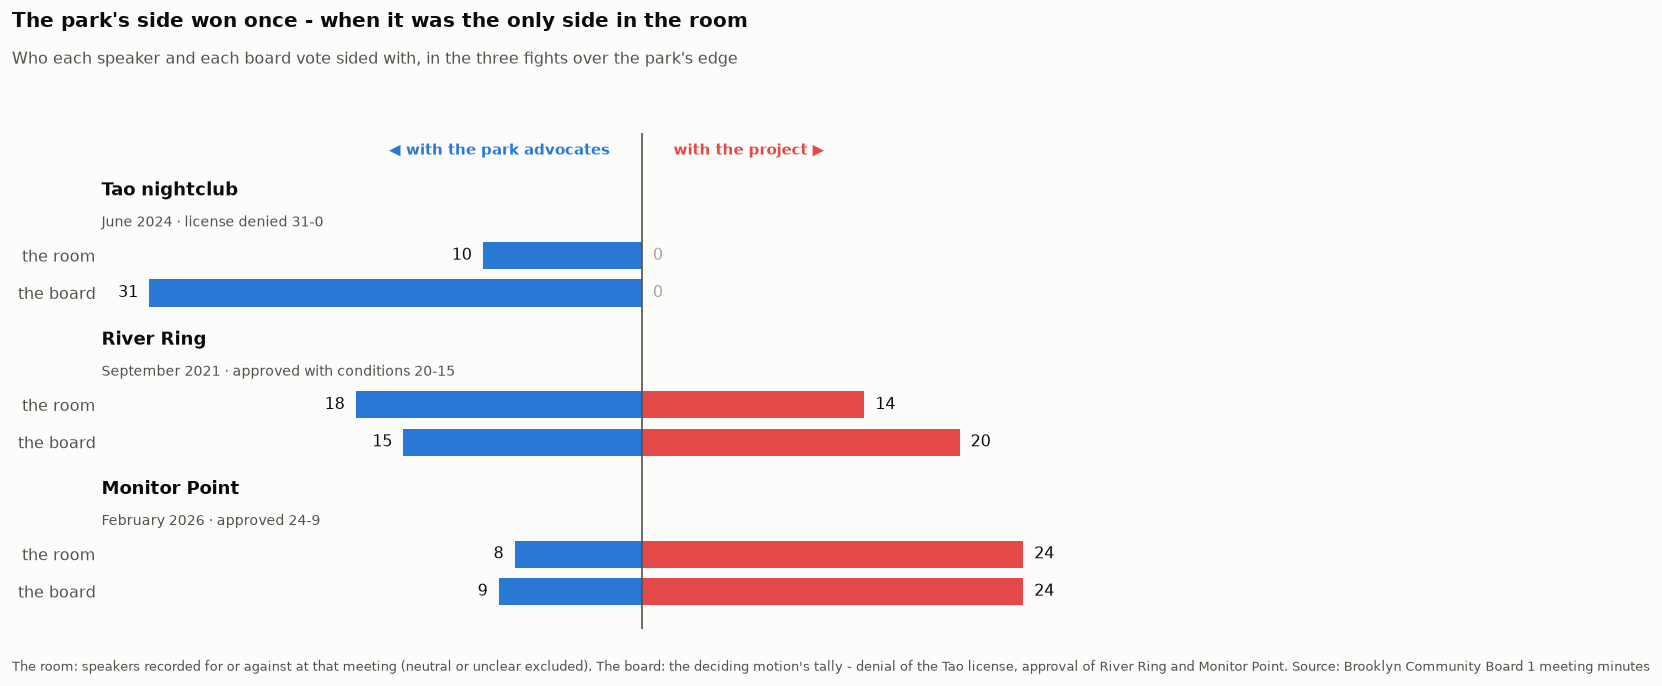

In [7]:
# Three fights over the park's edge, from the park advocates' side.
# In each one the advocates opposed the project, so a speaker "against" and a
# board vote against approval both count as siding with the park. The deciding
# motion at Tao was a denial, so there the yes votes are the advocates' side.
def room(date, pat):
    d = q(f"""SELECT position, count(*) AS n
              FROM speakers s JOIN meetings m USING (meeting_id)
              WHERE m.date = '{date}' AND regexp_matches(lower(s.topic), '{pat}')
              GROUP BY 1""").set_index("position").n
    return int(d.get("against", 0)), int(d.get("for", 0))

def board(date, pat):
    v = q(f"""SELECT yes, no FROM votes v JOIN meetings m USING (meeting_id)
              WHERE m.date = '{date}'
                AND regexp_matches(lower(v.motion_text), '{pat}')""")
    assert len(v) == 1
    return int(v.iloc[0].yes), int(v.iloc[0].no)

deny_y, deny_n = board("2024-06-18", "deny the application for franklin")
rr_y, rr_n = board("2021-09-14", "yes with the committee.s conditions")
mp_y, mp_n = board("2026-02-10", "to approve application monitor point")

fights = [
    ("Tao nightclub", "June 2024 · license denied 31-0",
     room("2024-06-18", "franklin"), (deny_y, deny_n)),
    ("River Ring", "September 2021 · approved with conditions 20-15",
     room("2021-09-14", "river ring"), (rr_n, rr_y)),
    ("Monitor Point", "February 2026 · approved 24-9",
     room("2026-02-10", "monitor point"), (mp_n, mp_y)),
]

fig, ax = plt.subplots(figsize=(10, 5.4), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ys, ylabels = [], []
for g, (name, sub, (r_adv, r_proj), (b_adv, b_proj)) in enumerate(fights):
    y0 = g * 3.4
    ax.text(-34, y0 - 0.78, name, fontsize=11, color=INK, fontweight="bold",
            ha="left", va="center")
    ax.text(-34, y0 - 0.05, sub, fontsize=8.5, color=INK2, ha="left", va="center")
    for row, (adv, proj) in enumerate([(r_adv, r_proj), (b_adv, b_proj)]):
        y = y0 + 0.7 + row * 0.85
        ax.barh(y, -adv, height=0.62, color=BLUE)
        ax.barh(y, proj, height=0.62, color=RED)
        ax.annotate(str(adv), (-adv - 0.7, y), ha="right", va="center",
                    fontsize=9.5, color=INK if adv else GRAY)
        ax.annotate(str(proj), (proj + 0.7, y), ha="left", va="center",
                    fontsize=9.5, color=INK if proj else GRAY)
        ys.append(y)
        ylabels.append("the room" if row == 0 else "the board")

ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(ys, ylabels, fontsize=9.5)
ax.set_ylim(9.2, -2.1)
ax.set_xlim(-34, 34)
ax.set_xticks([])
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(colors=INK2, length=0)
ax.annotate("◀ with the park advocates", (-2, -1.6), ha="right",
            fontsize=9, color=BLUE, fontweight="bold")
ax.annotate("with the project ▶", (2, -1.6), ha="left",
            fontsize=9, color=RED, fontweight="bold")
fig.suptitle("The park's side won once - when it was the only side in the room",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.9, "Who each speaker and each board vote sided with, in the three "
         "fights over the park's edge",
         fontsize=9.5, color=INK2)
fig.text(0.01, -0.02, "The room: speakers recorded for or against at that meeting "
         "(neutral or unclear excluded). The board: the deciding motion's tally - "
         "denial of the Tao license, approval of River Ring and Monitor Point. " + SRC,
         fontsize=8, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

This chart retells the three fights from the park advocates' side. Each fight gets two rows: who spoke at the hearing, and how the board voted on the deciding motion. Blue is the park's side. Red is the project's.

The board's split tracks the room's split. The advocates' one win came when nobody showed up for the other side - ten speakers against the Tao nightclub, zero for it, and the board denied the license 31-0. At Monitor Point the flow ran the other way: the project side filled the room 24 to 8, and the board landed at 24-9, almost the same ratio. River Ring is the only time the board crossed the room's majority - an 18-14 room against, a 20-15 board in favor. That decision split the board harder than 98% of the 1,155 tallied votes in the dataset.

Speakers aren't a poll. Turnout can be organized by either side, and at Monitor Point it was. The room measures who mobilized, not what the neighborhood wants.

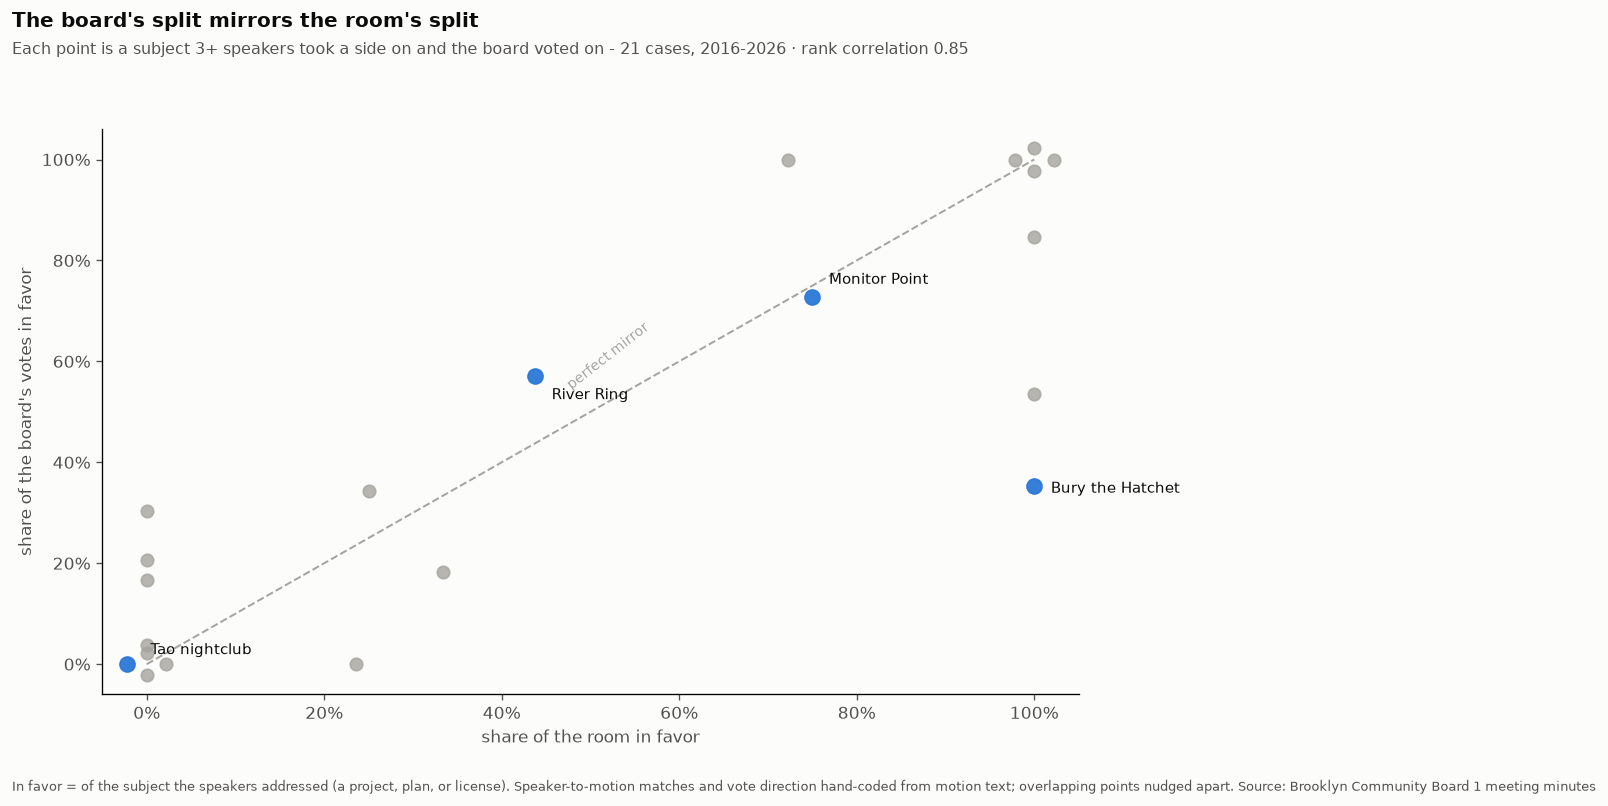

In [8]:
# Widen the net: every case where 3+ speakers took a side on a subject the
# board then voted on. The speaker-to-motion match and the motion's direction
# (does 'yes' side with the speakers' 'for'?) are hand-coded from the motion
# text; procedural motions and motions whose direction can't be recovered
# from the text are excluded. Columns: room for/against, board for/against.
MIRROR = pd.DataFrame([
    ("Metropolitan Ave bike lanes",    "2016-10-13",  3,  0, 34,  0),
    ("13-15 Greenpoint Ave amendment", "2017-01-10",  0,  7,  1, 25),
    ("Wburg Bridge access plan",       "2017-03-21",  5,  0, 29,  0),
    ("Transmitter Park concession",    "2017-05-09",  0,  4,  0, 31),
    ("Painting Lounge license",        "2017-11-14",  0,  4,  7, 16),
    ("Bury the Hatchet license",       "2018-12-11",  3,  0, 12, 22),
    ("10 Hope St license",             "2018-12-11",  1,  3, 11, 21),
    ("St. Paul's restoration",         "2019-01-08",  4,  0, 40,  0),
    ("Women's swim hours",             "2019-11-12",  4,  0, 22,  4),
    ("Meeker parking plan",            "2020-11-10",  0,  6,  0, 10),
    ("Meeker safety plan",             "2021-05-11", 13,  5, 14,  0),
    ("McGuinness redesign",            "2021-06-08", 24,  0,  8,  0),
    ("River Ring",                     "2021-09-14", 14, 18, 20, 15),
    ("BQE metered parking",            "2022-02-08",  1,  2,  2,  9),
    ("Monitor/Kingsland bike lanes",   "2022-06-07",  4, 13,  0, 29),
    ("Tao nightclub",                  "2024-06-18",  0, 10,  0, 31),
    ("Bedford Slip open street",       "2024-09-10",  0,  7,  6, 23),
    ("Maiz license",                   "2024-10-08",  0,  5,  0, 25),
    ("Baby's All Right sheds",         "2025-01-14",  0,  3,  6, 30),
    ("Monitor Point",                  "2026-02-10", 24,  8, 24,  9),
    ("Berry St traffic study",         "2026-06-09",  4,  0, 15, 13),
], columns=["label", "date", "rf", "ra", "bp", "ba"])
MIRROR["room"] = MIRROR.rf / (MIRROR.rf + MIRROR.ra)
MIRROR["board"] = MIRROR.bp / (MIRROR.bp + MIRROR.ba)

from scipy.stats import spearmanr
import statsmodels.api as sm
rho, _ = spearmanr(MIRROR.room, MIRROR.board)
mglm = sm.GLM(np.column_stack([MIRROR.bp, MIRROR.ba]),
              sm.add_constant(MIRROR.room),
              family=sm.families.Binomial()).fit(cov_type="HC1")

fig, ax = plt.subplots(figsize=(10, 6.4), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.plot([0, 1], [0, 1], ls="--", lw=1.2, color=GRAY, zorder=1)
ax.annotate("perfect mirror", (0.52, 0.545), fontsize=8.5, color=GRAY,
            rotation=38, ha="center")

# nudge exactly-overlapping corner points apart so all 21 are visible
pts = MIRROR.copy()
for (x, y), g in pts.groupby(["room", "board"]):
    if len(g) > 1:
        for k, idx in enumerate(g.index):
            ang = 2 * np.pi * k / len(g)
            pts.loc[idx, "room"] = x + 0.022 * np.cos(ang)
            pts.loc[idx, "board"] = y + 0.022 * np.sin(ang)

named = {"Tao nightclub": (14, 6), "River Ring": (10, -14),
         "Monitor Point": (10, 8), "Bury the Hatchet license": (10, -4)}
for _, p in pts.iterrows():
    hot = p.label in named
    ax.plot(p.room, p.board, "o", ms=9 if hot else 7.5,
            color=BLUE if hot else GRAY, alpha=0.95 if hot else 0.8, zorder=3)
    if hot:
        dx, dy = named[p.label]
        ax.annotate(p.label.replace(" license", ""), (p.room, p.board),
                    xytext=(dx, dy), textcoords="offset points",
                    fontsize=9, color=INK)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.06, 1.06)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("share of the room in favor", fontsize=10, color=INK2)
ax.set_ylabel("share of the board's votes in favor", fontsize=10, color=INK2)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=INK2)
fig.suptitle("The board's split mirrors the room's split",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.925, f"Each point is a subject 3+ speakers took a side on and the board "
         f"voted on - {len(MIRROR)} cases, 2016-2026 · rank correlation {rho:.2f}",
         fontsize=9.5, color=INK2)
fig.text(0.01, -0.02, "In favor = of the subject the speakers addressed (a project, "
         "plan, or license). Speaker-to-motion matches and vote direction hand-coded "
         "from motion text; overlapping points nudged apart. " + SRC,
         fontsize=8, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

Three fights is an anecdote, so I widened the net. I pulled every case in ten years of minutes where at least three speakers took a side on a subject and the board then voted on that subject. Matching speakers to motions took hand-coding - the minutes don't link them - and each motion's direction had to be read from its text. That left 21 clean cases. Each point compares the share of the room in favor of a subject with the share of the board's votes in favor of it.

The mirror holds. The rank correlation is 0.85, and in 19 of 21 cases the board's majority landed on the same side as the room's majority. A regression on these points says a room unanimously against a project predicts a board casting 11% of its votes for it. A room unanimously in favor predicts 84%. The number of speakers still doesn't matter - the balance of the room does. The two exceptions are worth naming. River Ring is one. The other is Bury the Hatchet, an axe-throwing bar - three speakers came out for it, nobody against, and the board denied the license 22-12 anyway.

Same caveat as before, and it matters more here: this is correlation. The room and the board may both be reading the same project on the same merits. And these 21 cases only exist where people took a side at the mic, which is its own filter.

## What about the letters?

Speaking at the mic isn't the only way to reach the board. The minutes bind letters and emails into the record - the Tao campaign alone accounts for over 200. Reading each one for its stance turns the mail into the same kind of evidence as the room: a count of who's on which side.

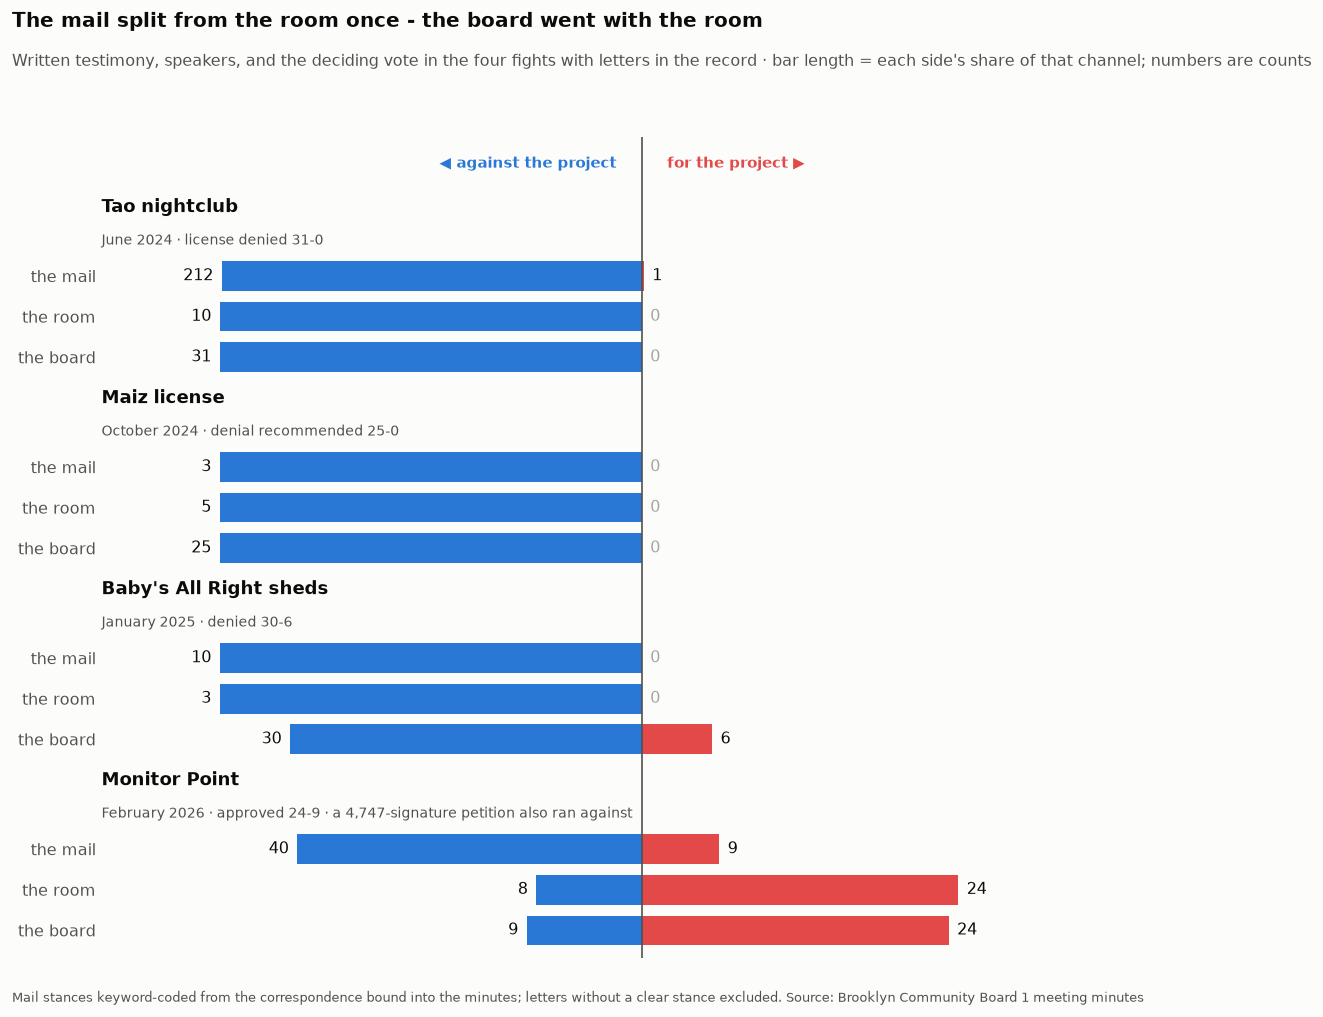

In [9]:
# The mail, with direction: split each meeting's attachment pages into
# individual letters/emails, match them to a fight, and keyword-code each
# item's stance. Spot-checked by hand against the source text; items whose
# stance the keywords can't call are excluded (see methodology).
def mail_counts(dates, pat):
    subj = re.compile(pat, re.I)
    s = pd.Series([_mail_stance(it) for d in dates
                   for it in _mail_items(_mid_by_date[d])
                   if subj.search(it)]).value_counts()
    return int(s.get("against", 0)), int(s.get("for", 0))

tao_y, tao_n = board("2024-06-18", "deny the application for franklin")
mz_y, mz_n = board("2024-10-08", "recommending the denial or revising")
ba_y, ba_n = board("2025-01-14", "outside shed")
# mp_y/mp_n (approve motion) already computed for the three-fights chart
mp_mail = mail_counts(["2026-01-20", "2026-02-10"], r"monitor point|40 quay|rezon")
tao_mail = mail_counts(["2024-06-18"], r"\btao\b|nightclub|11-25|franklin")
assert tao_mail[0] > 100 and mp_mail[0] > 3 * mp_mail[1], (tao_mail, mp_mail)

# (name, sub, mail(against,for), room(against,for), board(against,for))
MAIL_FIGHTS = [
    ("Tao nightclub", "June 2024 · license denied 31-0",
     tao_mail, room("2024-06-18", "franklin"), (tao_y, tao_n)),
    ("Maiz license", "October 2024 · denial recommended 25-0",
     mail_counts(["2024-10-08"], r"\bmaiz\b|10 hope"),
     room("2024-10-08", "maiz|10 hope"), (mz_y, mz_n)),
    ("Baby's All Right sheds", "January 2025 · denied 30-6",
     mail_counts(["2025-01-14"], r"baby.s all right|deux chats|146 broadway|shed"),
     room("2025-01-14", "baby.s all right|146 broadway|outdoor dining"), (ba_y, ba_n)),
    ("Monitor Point", "February 2026 · approved 24-9 · a 4,747-signature petition also ran against",
     mp_mail, room("2026-02-10", "monitor point"), (mp_n, mp_y)),
]

fig, ax = plt.subplots(figsize=(10, 8.2), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ys, ylabels = [], []
for g, (name, sub, (m_ag, m_for), (r_ag, r_for), (b_ag, b_for)) in enumerate(MAIL_FIGHTS):
    y0 = g * 4.0
    ax.text(-1.28, y0 - 0.72, name, fontsize=11, color=INK, fontweight="bold",
            ha="left", va="center")
    ax.text(-1.28, y0 - 0.02, sub, fontsize=8.5, color=INK2, ha="left", va="center")
    for row, (ag, fr) in enumerate([(m_ag, m_for), (r_ag, r_for), (b_ag, b_for)]):
        y = y0 + 0.72 + row * 0.85
        tot = ag + fr
        ax.barh(y, -ag / tot, height=0.62, color=BLUE)
        ax.barh(y, fr / tot, height=0.62, color=RED)
        ax.annotate(str(ag), (-ag / tot - 0.02, y), ha="right", va="center",
                    fontsize=9.5, color=INK if ag else GRAY)
        ax.annotate(str(fr), (fr / tot + 0.02, y), ha="left", va="center",
                    fontsize=9.5, color=INK if fr else GRAY)
        ys.append(y)
        ylabels.append(("the mail", "the room", "the board")[row])
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(ys, ylabels, fontsize=9.5)
ax.set_ylim(15.0, -2.2)
ax.set_xlim(-1.28, 1.28)
ax.set_xticks([])
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(colors=INK2, length=0)
ax.annotate("◀ against the project", (-0.06, -1.55), ha="right",
            fontsize=9, color=BLUE, fontweight="bold")
ax.annotate("for the project ▶", (0.06, -1.55), ha="left",
            fontsize=9, color=RED, fontweight="bold")
fig.suptitle("The mail split from the room once - the board went with the room",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.925, "Written testimony, speakers, and the deciding vote in the four "
         "fights with letters in the record · bar length = each side's share of that "
         "channel; numbers are counts", fontsize=9.5, color=INK2)
fig.text(0.01, -0.015, "Mail stances keyword-coded from the correspondence bound into "
         "the minutes; letters without a clear stance excluded. " + SRC,
         fontsize=8, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

For three of the four fights with mail in the record - Tao, the Maiz license, the Baby's All Right sheds - the letters, the mic, and the board all pointed the same way. 212 emails against the nightclub, ten speakers against, license denied 31-0.

Monitor Point is the only fight where the channels split, and it settles the question. The mail ran four to one against the rezoning. A 4,747-signature petition ran against it. The room ran three to one in favor - union locals and the developer's own team filled the seats. The board landed at 24-9, the room's ratio almost exactly. When the mail and the mic disagreed, the board went with the bodies in the room.

One divergent case is thin evidence on its own. But it points the same way as everything else here: the channel the board reflects is the one with people standing in it.

## So what role can the community play in developing this land into a park?

One outright win in ten years, and it was denying a nightclub, not building a park. But that undersells what community involvement is capable of. The community played a role in creating specific asks and conditions on these votes. Ten years of minutes point at one lever: the Land Use hearings. And volume of involvement alone doesn't move the needle - specific requests backed by the community do.

![One of the fenced-off lots at the park's edge, July 2026: cracked asphalt, weeds, and a skyline view going unused. Photo: author](images/lots_fence.jpg)

## Methodology

The dataset comes from the PDF meeting minutes CB1 posts publicly - 138 files covering 110 meetings from 2016 to 2026, about 22,000 pages. I extracted structured records (votes, liquor licenses, public speakers) with a custom ETL pipeline leveraging LLMs via AWS Bedrock to scan and extract data points. I hand-verified a subset of data points from three sample meetings against the original PDFs: vote tallies matched 38 of 38, license records 144 of 144, and speaker recall was 97%. Every extracted record keeps a verbatim quote from the source PDF, so any claim in this post can be traced back to a page. One extraction gap surfaced during this analysis - the September 2021 roll-call section, including the River Ring votes, had been misfiled as an attachment - and was recovered by hand from the minutes text, with the fix documented in the dataset.

Three disclaimers:

1. The waterfront vote panel is small - 26 votes, and one night (February 2026) contributes three of them.
2. Everything stated above is association, not causation: big projects generate both turnout and division, and this data can't say which causes which.
3. Written-testimony stances are keyword-coded from the correspondence bound into the minutes and spot-checked by hand, not independently verified. Letters without a clear keyword stance are excluded from the mail tallies. Correspondence is only bound into the minutes from about 2022, so the written channel is invisible before then.

The full pipeline, analysis notebooks, and the extracted dataset are on GitHub: [blowenstein0/cb1_data_analysis](https://github.com/blowenstein0/cb1_data_analysis).